In [1]:
from keras.datasets import fashion_mnist as fm;
from keras.utils import to_categorical
from keras import layers,models,regularizers
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

/Users/ponlawatchangto/Desktop/VsCode/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
(train_x,train_y),(test_x,test_y) = fm.load_data()

In [3]:
print(f"train_x.shape : {train_x.shape}")
print(f"train_y.shape : {train_y.shape}")
print(f"test_x.shape : {test_x.shape}")
print(f"test_y.shape : {test_y.shape}")

train_x.shape : (60000, 28, 28)
train_y.shape : (60000,)
test_x.shape : (10000, 28, 28)
test_y.shape : (10000,)


In [4]:
train_x = train_x.reshape((60000,28*28))
test_x = test_x.reshape((10000,28*28))

# train_y = to_categorical(train_y)
# test_y = to_categorical(test_y)

In [5]:
val_x = train_x[40000:]
val_y = train_y[40000:]

train_x = train_x[:40000]
train_y = train_y[:40000]

In [6]:
print(f"train_x.shape : {train_x.shape}")
print(f"train_y.shape : {train_y.shape}")
print(f"val_x.shape : {val_x.shape}")
print(f"val_y.shape : {val_y.shape}")
print(f"test_x.shape : {test_x.shape}")
print(f"test_y.shape : {test_y.shape}")

train_x.shape : (40000, 784)
train_y.shape : (40000,)
val_x.shape : (20000, 784)
val_y.shape : (20000,)
test_x.shape : (10000, 784)
test_y.shape : (10000,)


In [7]:
# model = models.Sequential([
#     layers.Dense(50,activation='relu',input_shape=(784,)) ,
#     layers.Dense(32,activation='relu'),
#     layers.Dense(10,activation='softmax')
# ])

# model = models.Sequential([
#     layers.Dense(64,activation='relu',input_shape=(28*28,)),
#     layers.Dense(10,activation='softmax')
# ])

model = models.Sequential([
    layers.Dense(128, activation='relu',kernel_regularizer=regularizers.l2(0.001), input_shape=(784,)),
    layers.Dense(24,kernel_regularizer=regularizers.l2(0.001), activation='relu'),
    layers.Dense(24,kernel_regularizer=regularizers.l2(0.001), activation='relu'),
    layers.Dense(10,activation='sigmoid'),
])

model.compile(optimizer='rmsprop',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/Users/ponlawatchangto/Desktop/VsCode/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
history = model.fit(train_x,train_y,epochs=10,batch_size=100,validation_data=(val_x,val_y))

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3015 - loss: 2.6050 - val_accuracy: 0.3119 - val_loss: 1.5215
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step - accuracy: 0.3612 - loss: 1.4369 - val_accuracy: 0.4900 - val_loss: 1.0204
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - accuracy: 0.5563 - loss: 0.9119 - val_accuracy: 0.6047 - val_loss: 0.7405
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - accuracy: 0.6981 - loss: 0.7055 - val_accuracy: 0.7833 - val_loss: 0.6348
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - accuracy: 0.7866 - loss: 0.6081 - val_accuracy: 0.8181 - val_loss: 0.5749
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - accuracy: 0.8227 - loss: 0.5511 - val_accuracy: 0.8379 - val_loss: 0.5217
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - accuracy: 0.8365 - loss: 0.5158 - val_accuracy: 0.8426 - val_loss: 0.5334
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - accuracy: 0.8472 - loss: 0.4951 - va

In [9]:
def plot(history,name="") :
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.figure(figsize=(15,7))
    
    plt.subplot(1,2,1)
    plt.plot(epochs,loss,'r',label='Training loss')
    plt.plot(epochs,val_loss,'b',label='Validation loss')
    plt.title('Training and Validation Loss '+ name)
    plt.grid(True)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1,2,2)
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1 , len(accuracy) + 1)
    plt.plot(epochs,accuracy,'r',label='Training Accuracy')
    plt.plot(epochs,val_accuracy,'b',label='Validation Accuracy')
    plt.title('Training and Validation Accuracy ' + name)
    plt.grid(True)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
    print(f"min val_loss : {min(val_loss)}")
    print(f"max val_acc : {max(val_accuracy)}")
    print(f"Latest val_loss : {val_loss[len(val_loss)-1]}")
    print(f"Latest val_acc : {val_accuracy[len(val_accuracy)-1]}")

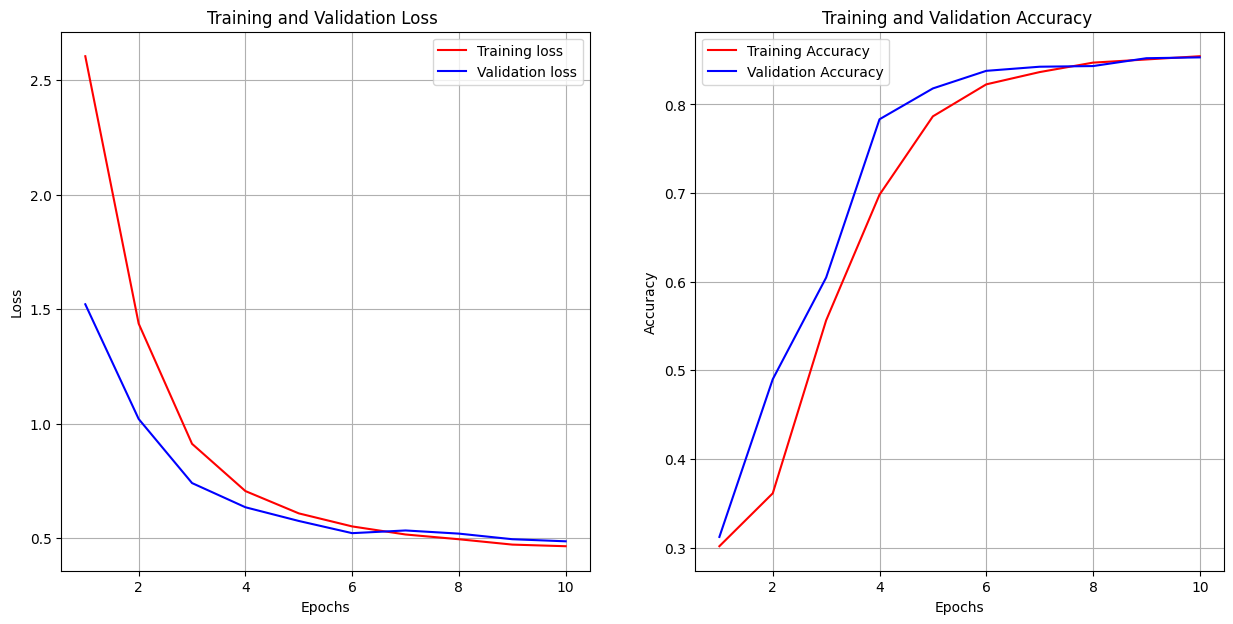

min val_loss : 0.4860445261001587
max val_acc : 0.8531500101089478
Latest val_loss : 0.4860445261001587
Latest val_acc : 0.8531500101089478
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - accuracy: 0.8418 - loss: 0.5098
0.5097786784172058 0.8417999744415283


In [10]:
plot(history)
loss , acc = model.evaluate(test_x,test_y)
print(loss,acc)

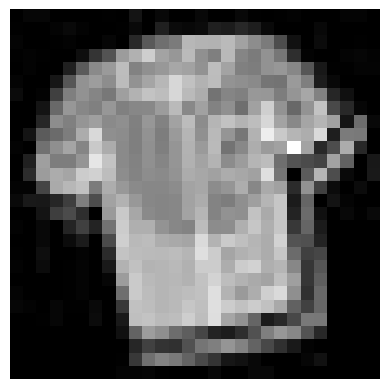

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Predicted : 6
ความมั่นใจ: 95.75%


In [11]:
filename = f"Shirt.jpg"
img = load_img(filename,color_mode='grayscale',target_size=(28,28))

img_array = img_to_array(img)
img_array = 255.0 - img_array

img_array = img_array.reshape((1,28*28)).astype('float32')/255.0

plt.imshow(img_array.reshape(28,28) , cmap='gray')
plt.axis('off')
plt.show()

prediction = history.model.predict(img_array)
predicted_digit = np.argmax(prediction)

print(f"Predicted : {predicted_digit}")
print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")

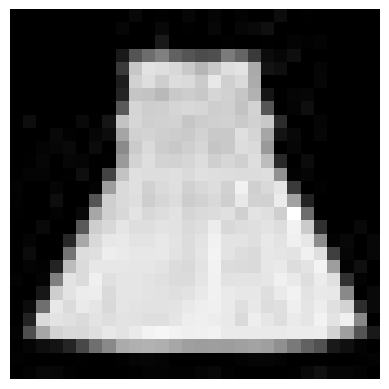

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Predicted : 6
ความมั่นใจ: 95.60%


In [12]:
filename = f"Dress.jpg"
img = load_img(filename,color_mode='grayscale',target_size=(28,28))

img_array = img_to_array(img)
img_array = 255.0 - img_array

img_array = img_array.reshape((1,28*28)).astype('float32')/255.0

plt.imshow(img_array.reshape(28,28) , cmap='gray')
plt.axis('off')
plt.show()

prediction = history.model.predict(img_array)
predicted_digit = np.argmax(prediction)

print(f"Predicted : {predicted_digit}")
print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")

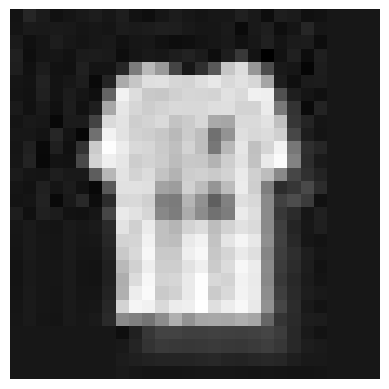

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Predicted : 6
ความมั่นใจ: 95.67%


In [13]:
filename = f"T-shirt.jpg"
img = load_img(filename,color_mode='grayscale',target_size=(28,28))

img_array = img_to_array(img)
img_array = 255.0 - img_array

img_array = img_array.reshape((1,28*28)).astype('float32')/255.0

plt.imshow(img_array.reshape(28,28) , cmap='gray')
plt.axis('off')
plt.show()

prediction = history.model.predict(img_array)
predicted_digit = np.argmax(prediction)

print(f"Predicted : {predicted_digit}")
print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")